In [1]:
import numpy as np
from numpy import linalg as la
from numpy.linalg import inv

# We want to suppress printing of small floating point values using scientific notation
np.set_printoptions(suppress=True)

#create a matrix
A = np.array([1,2,3,0,-4,1,0,3,-1]).reshape(3,3)
print("A=")
print(A)

#calculate the determinant
det = la.det(A)
print(f"Determinant of A is: {det:.6f}")

#solve a set of equations
b = np.array([2,2,-1])
X = la.solve(A, b)  # Unpacking is also possible with NumPy arrays
x, y, z = X         # Unpack tuple
print(f"\nSolution x, y, z={x:.6f}, {y:.6f}, {z:.6f}")

#A orthogonal
print(f"\nA.AT should be the identity matrix:\n{A@A.T}\n{A@A.T == np.identity(3)}")


#Eigenvalue
Lambda, v = la.eig(A)
print("Lambda = ", Lambda)


A=
[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]
Determinant of A is: 1.000000

Solution x, y, z=10.000000, -1.000000, -2.000000

A.AT should be the identity matrix:
[[ 14  -5   3]
 [ -5  17 -13]
 [  3 -13  10]]
[[False False False]
 [False False False]
 [False False False]]
Lambda =  [ 1.         -4.79128785 -0.20871215]


In [2]:
import numpy as np
from numpy import linalg as la
from numpy.linalg import inv
from numpy.linalg import norm

# We want to suppress printing of small floating point values using scientific notation
np.set_printoptions(suppress=True)

#create composed matrix E
x1=np.radians(180-123)
x2=np.radians(90-27.4)
x3=np.radians(192.25)

Ez1=np.array([np.cos(x1),np.sin(x1),0,-np.sin(x1),np.cos(x1),0,0,0,1]).reshape(3,3)
Ey=np.array([np.cos(x2),0,-np.sin(x2),0,1,0,np.sin(x2),0,np.cos(x2)]).reshape(3,3)
Ez2=np.array([np.cos(x3),np.sin(x3),0,-np.sin(x3),np.cos(x3),0,0,0,1]).reshape(3,3)

E= Ez1@Ey@Ez2
print(E)

#prove its rotation matrix
#properties of a rotation matrix
#E^TxE=I
#det(E)=1

I=E.T@E
det = la.det(E)
print(f"Determinant of E is: {det:.6f}")
print(f"identity matrix: {I}")


#Eigenvalue of E
Lambda, v = la.eig(E)
print("Lambda = ", Lambda)

#galactic pole
alpha=np.radians(192.25)
delta=np.radians(27.4)
v=np.array([np.cos(delta)*np.cos(alpha),np.cos(delta)*np.sin(alpha),np.sin(delta)])
print(f"v= {v}")

#norm
L = norm(v)
print(f"The length of v={L}")

#rotation with E
v1=E@v
print(f"v1 {v1}")

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]
Determinant of E is: 1.000000
identity matrix: [[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]
Lambda =  [-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]
v= [-0.86760081 -0.1883746   0.46019978]
The length of v=1.0
v1 [0. 0. 1.]


the coefficients: [ 218.582332   -551.00314615  565.81223725 -313.63355584  104.54407428
  -21.93313595    2.91867715   -0.23905976    0.01099256   -0.00021712]
9.9


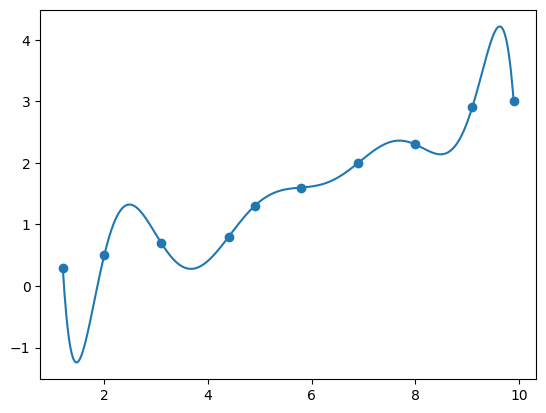

In [3]:
import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

n=len(x)

#matrix with just zeros
M=np.zeros((n,n))

#create polynomial
for i in range(n):
    for j in range(n):
        M[i,j]=x[i]**j

#solve for coefficients
c=la.solve(M,y)
print(f"the coefficients: {c}")

#create polynomial data for plotting
x_new=np.linspace(1.2,9.9,500)

print(np.max(x))
y_new=0
for i in range (n):
    y1=c[i]*x_new**i
    y_new+=y1
    
plt.scatter(x,y)
plt.plot(x_new, y_new)
plt.show()

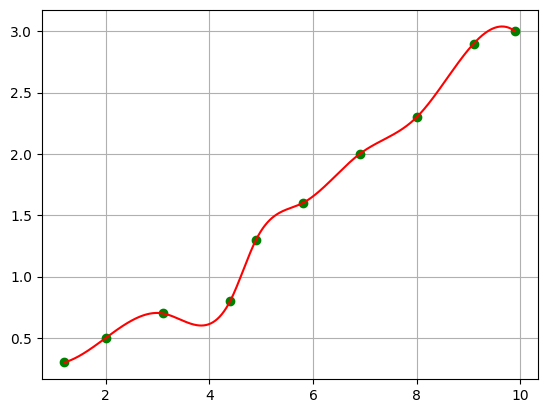

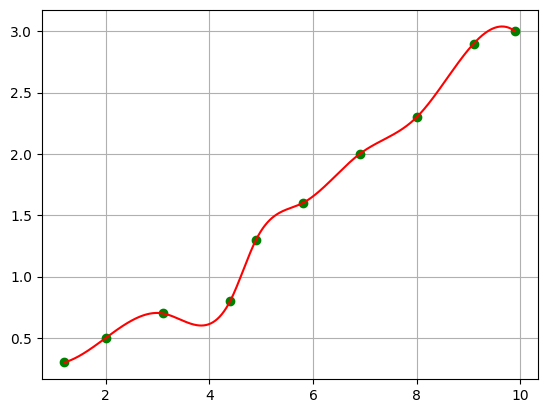

1.5


In [4]:
import numpy as np
from matplotlib.pyplot import figure, show
from scipy import interpolate as ip

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

f = ip.interp1d(x, y, kind='cubic')

newx = np.linspace(1.2,9.9,1000)  # notice outside the original domain
newy = f(newx)

#plot interpolating spline
fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(x, y, 'go')
frame.plot(newx, newy, 'r')
frame.grid(True)
show()

#create interpolation class

class interpolation:
    def __init__(self, x, y):
        self.x=x
        self.y=y
    def linear(self):
        f = ip.interp1d(self.x, self.y, kind='linear')
        return f
    def polynomial(self):
        n=len(self.x)
        M=np.zeros((n,n))
        for i in range(n):
            for j in range(n):
                    M[i,j]=self.x[i]**j
        c=la.solve(M,y)
        def f(x1):
            y_new=0
            for i in range (n):
                y1=c[i]*x1**i
                y_new+=y1
            return y_new
        return f
    def spline(self):
        f = ip.interp1d(self.x, self.y, kind='cubic')
        return f
    def method(self, method, x1):
        xnew = np.linspace(np.min(self.x),np.max(self.x),500)
        if method=="linear":
            f=self.linear()
        elif method=="polynomial":
            f=self.polynomial()
        elif method=="spline":
            f=self.spline()
        else:
            return f"does not work"
        
        ynew=f(xnew)
        
        fig = figure()
        frame = fig.add_subplot(1,1,1)
        frame.plot(x, y, 'go')
        frame.plot(newx, newy, 'r')
        frame.grid(True)
        show()
        
        return f(x1)
    
inter=interpolation(x,y)

print(inter.method("linear", 5.5))

In [5]:
from scipy.interpolate import RegularGridInterpolator
import numpy as np


I = np.array([[2.0,4.1], [2.5,3.8]])
print(I)

rowindices = range(I.shape[0])
colindices = range(I.shape[1])

col_x = 0.2
row_y = 0.7

# Interpolator example: https://gist.github.com/ev-br/8544371b40f414b7eaf3fe6217209bff
do_interpol = RegularGridInterpolator( (colindices, rowindices), I.T, method='linear')
Iintp = do_interpol ((col_x, row_y) )
print(f"The interpolated intensity at x,y={col_x},{row_y} is {Iintp}")



[[2.  4.1]
 [2.5 3.8]]
The interpolated intensity at x,y=0.2,0.7 is 2.658


[69.93819296 64.13233139]
Intercept beta0=69.93784038489176, slope beta1=64.13234086711788


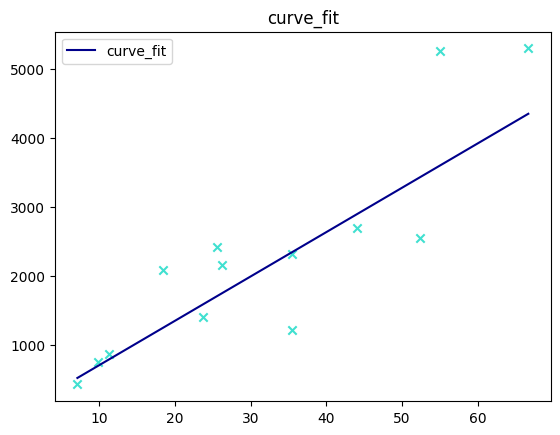

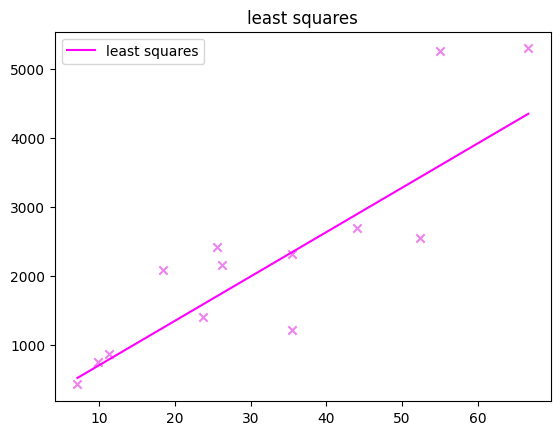

In [19]:
import numpy as np
from scipy.optimize import leastsq
from matplotlib.pyplot import subplots, show
from scipy.optimize import curve_fit

data =[
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]

data=np.asarray(data)

x=data[0::4]
y=data[1::4]
sigx=data[2::4]
sigy=data[3::4]

#using leastsq()
# The model, usually a function of x
def model_lsq(beta, x):
    beta0, beta1 = beta
    return beta0 + beta1*x

# A residuals function
def residuals(beta, x, y, sigy):
    return (y - model_lsq(beta,x))/sigy

beta_start = [0, 70.0]          # Initial estimates for beta0 and beta1
result = leastsq(residuals, beta_start, args=(x,y,sigy), full_output=1)
(beta, pcov, infodict, errmsg, ier) = result       # Unpack tuple with results

beta_lsqwei = beta
print(beta_lsqwei)

#using curve_fit
def model_cf(x, beta0, beta1):
    """The model with parameters a and b. Note that for the Hubble relation we fix a to 0.0"""
    return beta0 + beta1*x

# Do the fitting
beta, pcov = curve_fit(model_cf, x, y, sigma=sigy)
print(f"Intercept beta0={beta[0]}, slope beta1={beta[1]}")

#plot curve_fit
X = np.array([x.min(),x.max()])
Y = model_cf(X, beta[0], beta[1])

fig = figure()
frame1 = fig.add_subplot(1,1,1)
#plot data
frame1.scatter(x, y, marker='x', color="turquoise")
#plot curve_fit
frame1.plot(X, Y, label="curve_fit", color='darkblue')
frame1.set_title("curve_fit")
frame1.legend()
show()
#plot least squares
fig = figure()
frame2 = fig.add_subplot(1,1,1)
#plot data
frame2.scatter(x, y, marker='x', color="violet")
xmin = x.min(); xmax = x.max()
ymin = model_lsq(beta_lsqwei,xmin); ymax = model_lsq(beta_lsqwei,xmax)
frame2.plot([xmin, xmax], [ymin, ymax], label="least squares", color='magenta')
frame2.set_title("least squares")
frame2.legend()
show()